# Trade review

This notebook analyses two trade journals produced by **ForexReplay**:

1. **`impulse_candle`**: trades I took by hand in the bar-replay window (22 trades over two replays of 3–17 March 2025).
2. **`asian_breakout`**: an automated example strategy backtested on all 100k+ EURUSD M5 candles (Feb 2025 to Jul 2026) with a 0.2 pip spread.

Everything is measured in **R** (multiples of the risk taken on each trade), so results don't depend on account size.
Times are in the data's broker-server clock (UTC+2/+3), where London opens at 10:00.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from forex_replay.journal import load_journal
from forex_replay.stats import breakdown, compute_stats, format_report
from forex_replay.plotting import plot_breakdown, plot_equity

pd.set_option("display.precision", 2)
manual = load_journal(ROOT / "strategies/impulse_candle/trades.csv")
auto = load_journal(ROOT / "results/asian_breakout/trades.csv")
len(manual), len(auto)

(22, 204)

## 1. Manual strategy: impulse candle

In [2]:
print(format_report(manual))

=============== STATISTICS ===============
Trades            : 22  (W 12 / L 10 / BE 0)
Win rate          : 54.5%
Average win       : +0.54 R
Average loss      : -1.00 R
Payoff ratio      : 0.54
Expectancy        : -0.16 R per trade
Total             : -3.53 R
Profit factor     : 0.65
Max drawdown      : 4.60 R
Longest win/loss  : 3 / 3 trades
Average MFE       : 3.14 R  (only 1 trade(s) have MFE recorded)
Average duration  : 31 min

At 1% risk per trade (typical challenge: 8% target, 5% daily, 10% max loss):
  Return -3.5% | max drawdown 4.6% | worst day -1.0%
  target not reached, daily limit ok, max loss ok

By session:
         trades win_rate total_r expectancy_r
session                                      
London       14      64%   -0.04        -0.00
Asia          8      38%   -3.49        -0.44


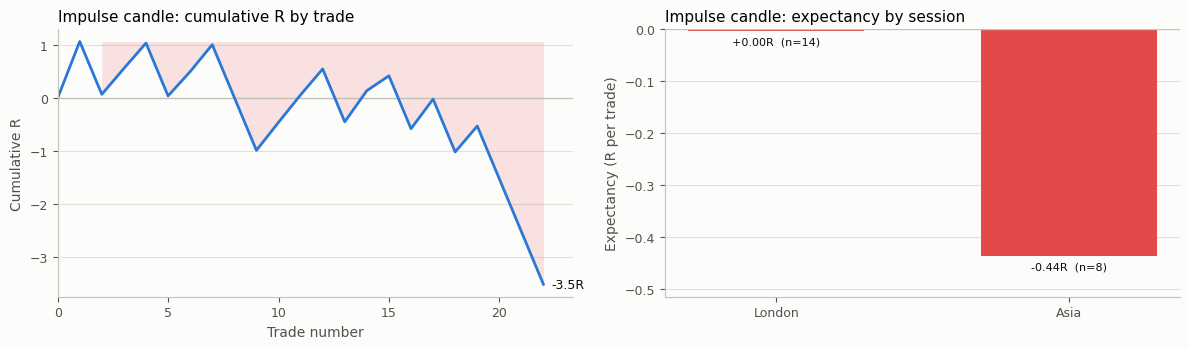

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_equity(manual, "Impulse candle: cumulative R by trade", ax=axes[0])
plot_breakdown(manual, "session", "Impulse candle: expectancy by session", ax=axes[1])
fig.tight_layout()

### Why is it losing with a 55% win rate?

Because the targets are small. With a winner worth *w* R and a loser costing 1R, the win rate needed just to break even is 1 / (1 + *w*).

In [4]:
wins = manual[manual["result_r"] > 0.05]
avg_win = wins["result_r"].mean()
summary = pd.Series({
    "median planned reward (R)": manual["planned_rr"].median(),
    "average win (R)": avg_win,
    "win rate needed to break even": 1 / (1 + avg_win),
    "actual win rate": (manual["result_r"] > 0.05).mean(),
})
summary.to_frame("value")

,value
median planned reward (R),0.50
average win (R),0.54
win rate needed to break even,0.65
actual win rate,0.55


In [5]:
manual.groupby("run_id")["result_r"].agg(trades="count", total_r="sum", expectancy_r="mean").round(2)

,trades,total_r,expectancy_r
run_id,,,
legacy-run-1,11,0.06,0.01
legacy-run-2,11,-3.59,-0.33


**Takeaways**

- Almost every target was set at about **0.5R**. That needs roughly a **65% win rate** to break even, and the replays achieved **55%**, so the edge is negative (about −0.16R per trade).
- The two replays of the *same* two weeks gave very different results (≈0R vs −3.6R). With only 11 trades per run, most of the difference is noise, so a larger sample is needed before judging the setup itself.
- Trades before the London open (the "Asia" bucket, before 10:00 server time) did clearly worse than trades after it.
- Next step: test the same entries with a 1R–1.5R target, and log MFE on every trade (the app now does this automatically) to see whether bigger targets were actually reachable.

## 2. Automated example: Asian-range breakout

In [6]:
print(format_report(auto))

=============== STATISTICS ===============
Trades            : 204  (W 83 / L 121 / BE 0)
Win rate          : 40.7%
Average win       : +1.41 R
Average loss      : -0.99 R
Payoff ratio      : 1.42
Expectancy        : -0.02 R per trade
Total             : -3.51 R
Profit factor     : 0.97
Max drawdown      : 28.61 R
Longest win/loss  : 6 / 9 trades
Average MFE       : 0.87 R
Average duration  : 190 min

At 1% risk per trade (typical challenge: 8% target, 5% daily, 10% max loss):
  Return -3.5% | max drawdown 28.6% | worst day -1.0%
  target not reached, daily limit ok, MAX LOSS BREACHED

By session:
                   trades win_rate total_r expectancy_r
session                                                
London                201      40%   -5.88        -0.03
London/NY overlap       3      67%   +2.37        +0.79


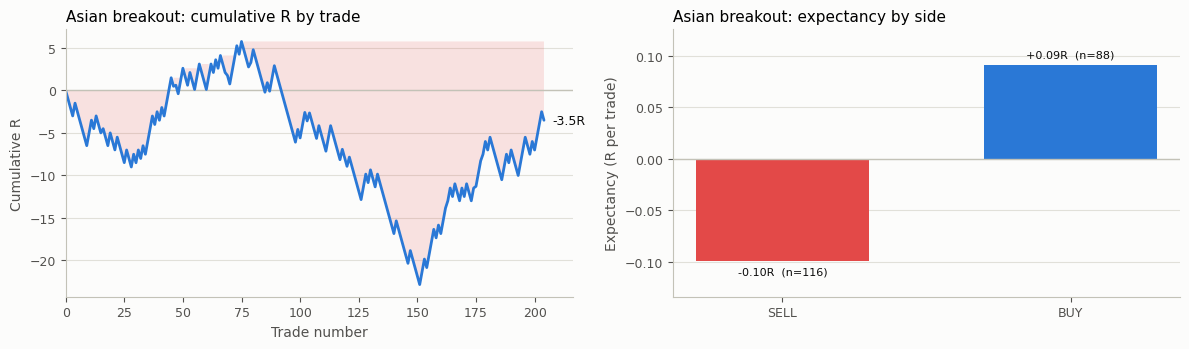

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_equity(auto, "Asian breakout: cumulative R by trade", ax=axes[0])
plot_breakdown(auto, "side", "Asian breakout: expectancy by side", ax=axes[1])
fig.tight_layout()

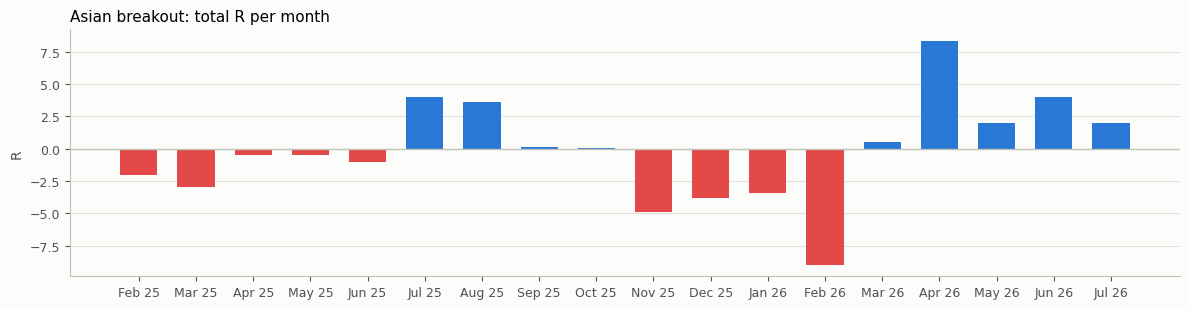

In [8]:
from forex_replay.plotting import PALETTE, _style

monthly = auto.groupby(auto["exit_time"].dt.to_period("M"))["result_r"].sum()
fig, ax = plt.subplots(figsize=(12, 3.2))
_style(ax)
colors = [PALETTE["positive"] if v >= 0 else PALETTE["negative"] for v in monthly]
ax.bar(monthly.index.strftime("%b %y"), monthly.to_numpy(), color=colors, width=0.65)
ax.axhline(0, color=PALETTE["axis"], linewidth=1)
ax.set_title("Asian breakout: total R per month", loc="left", fontsize=11)
ax.set_ylabel("R")
fig.tight_layout()

In [9]:
auto["exit_reason"].value_counts().to_frame("trades")

,trades
exit_reason,
STOP_LOSS,120
TAKE_PROFIT,73
MANUAL,11


**Takeaways**

- About **breakeven before costs, slightly negative after a 0.2 pip spread** (profit factor ≈ 0.97 over 204 trades).
- Results come in regimes: a long losing stretch from Nov 2025 to Feb 2026 and a strong run in Apr–Jun 2026. The **~29R max drawdown** would fail a 10% max-loss prop-firm rule at 1% risk per trade.
- Average MFE is ~0.9R against a 1.5R target: many trades move into profit but reverse before the target.
- This strategy is only here to show the automated mode. It is not a strategy to trade.